In [72]:
# run this by itself to run r 
%load_ext rpy2.ipython

The rpy2.ipython extension is already loaded. To reload it, use:
  %reload_ext rpy2.ipython


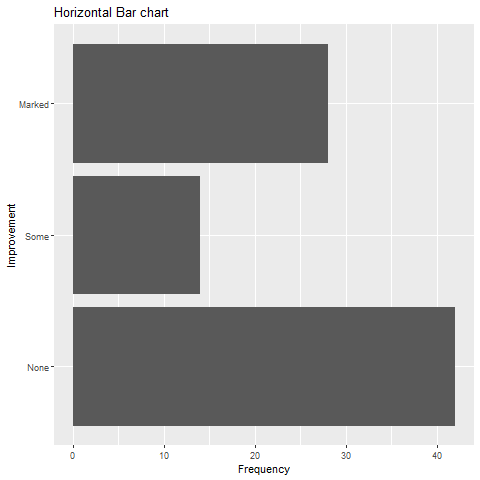

In [73]:
%%R
# install.packages(c("ggplot2", "vcd", "dplyr", "treemapify", "scales"))# 
#-----------------------------------------------------------------------#

# Listing 6.1 Simple bar charts
library(ggplot2)
data(Arthritis, package="vcd")
ggplot(Arthritis, aes(x=Improved, fill=Improved)) + geom_bar() +
  labs(title="Simple Bar chart",                 
       x="Improvement",                          
       y="Frequency")                            

ggplot(Arthritis, aes(x=Improved)) + geom_bar() +
  labs(title="Horizontal Bar chart",             
       x="Improvement",                          
       y="Frequency") +                          
  coord_flip()                    

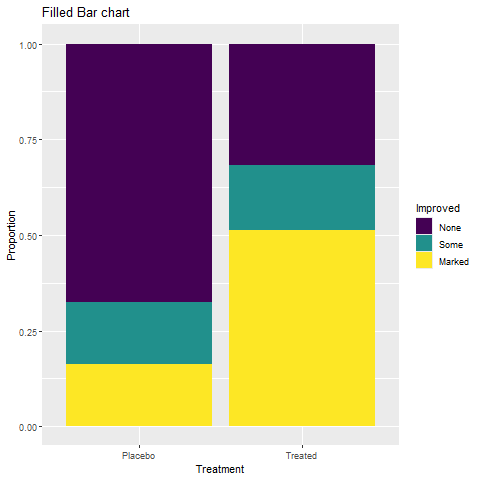

In [74]:
%%R
# Listing 6.2 Stacked, grouped, and filled bar charts
ggplot(Arthritis, aes(x=Treatment, fill=Improved)) +
  geom_bar(position = "stack") +  
  labs(title="Stacked Bar chart",                   
       x="Treatment",                               
       y="Frequency")                               

ggplot(Arthritis, aes(x=Treatment, fill=Improved)) +
  geom_bar(position = "dodge") + 
  labs(title="Grouped Bar chart",                   
       x="Treatment",                               
       y="Frequency")                               

ggplot(Arthritis, aes(x=Treatment, fill=Improved)) +
  geom_bar(position = "fill") +  
  labs(title="Filled Bar chart",                   
       x="Treatment",                               
       y="Proportion") 

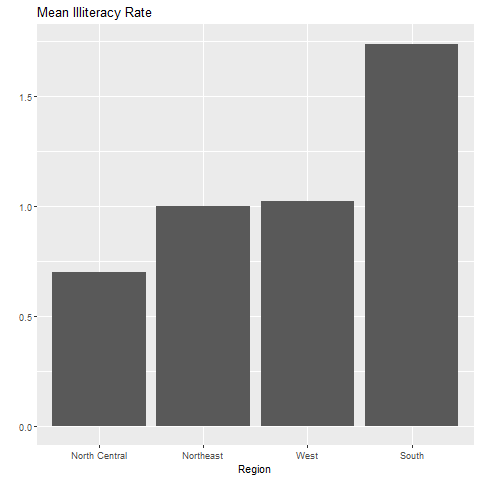

In [75]:
%%R
# Listing 6.3 Bar chart for sorted mean values
states <- data.frame(state.region, state.x77)    

library(dplyr)                 
plotdata <- states %>% 
group_by(state.region) %>%
summarize(mean = mean(Illiteracy))
plotdata

ggplot(plotdata, aes(x=reorder(state.region, mean), y=mean)) + 
  geom_bar(stat="identity") +
  labs(x="Region",
  y="",
  title = "Mean Illiteracy Rate")

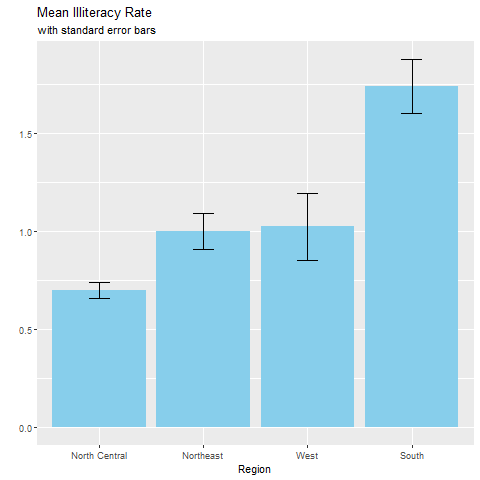

In [76]:
%%R
# Listing 6.4 Bar chart of mean values with error bars
plotdata <- states %>%
group_by(state.region) %>%
summarize(n=n(), 
          mean = mean(Illiteracy),                      
          se = sd(Illiteracy)/sqrt(n))                  

plotdata

ggplot(plotdata, aes(x=reorder(state.region, mean), y=mean)) +
geom_bar(stat="identity", fill="skyblue") +
geom_errorbar(aes(ymin=mean-se, ymax=mean+se), width=0.2) +
labs(x="Region",
     y="",
     title = "Mean Illiteracy Rate",
     subtitle = "with standard error bars")


Please download and install Rtools 4.5 from https://cran.r-project.org/bin/windows/Rtools/.
Using GitHub PAT from the git credential store.
Skipping install of 'ggpie' from a github remote, the SHA1 (0316ac35) has not changed since last install.
  Use `force = TRUE` to force installation
In addition: Warning messages:
1: In geom_col(width = 1, size = border.width, col = border.color) :
  Ignoring unknown parameters: `size`
2: In geom_col(width = 1, size = border.width, col = border.color) :
  Ignoring unknown parameters: `size`
3: In geom_col(width = 1, size = border.width, col = border.color) :
  Ignoring unknown parameters: `size`


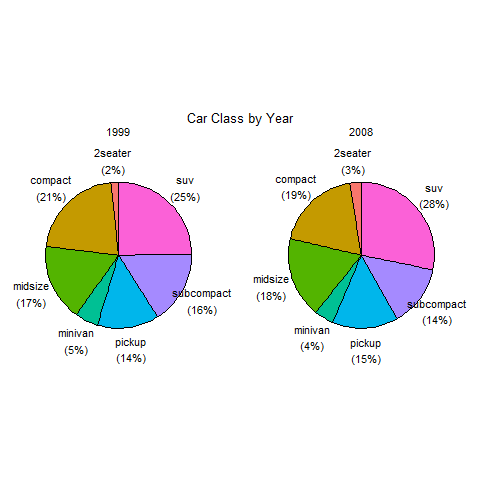

In [77]:
%%R
# Figure 6.5 Bar chart
data(Arthritis, package="vcd")
ggplot(Arthritis, aes(x=Improved)) + 
  geom_bar(fill="gold", color="black") +
  labs(title="Treatment Outcome") 

# Bar chart labels
ggplot(mpg, aes(x=model)) + 
  geom_bar() +
  labs(title="Car models in the mpg dataset", 
       y="Frequency", x="") 

ggplot(mpg, aes(x=model)) + 
  geom_bar() +
  labs(title="Car models in the mpg dataset", 
       y="Frequency", x="") +
  coord_flip() 

ggplot(mpg, aes(x=model)) + 
  geom_bar() +
  labs(title="Model names in the mpg dataset", 
       y="Frequency", x="") +
  theme(axis.text.x = element_text(angle = 45, hjust = 1, size=8)) 


# Pie charts
if(!require(remotes)) install.packages("remotes")
   devtools::install_github("rkabacoff/ggpie")

library(ggplot2)
library(ggpie)
ggpie(mpg, class)

ggpie(mpg, class, legend=FALSE, offset=1.3, 
      title="Automobiles by Car Class")

ggpie(mpg, class, year, 
      legend=FALSE, offset=1.3, title="Car Class by Year")


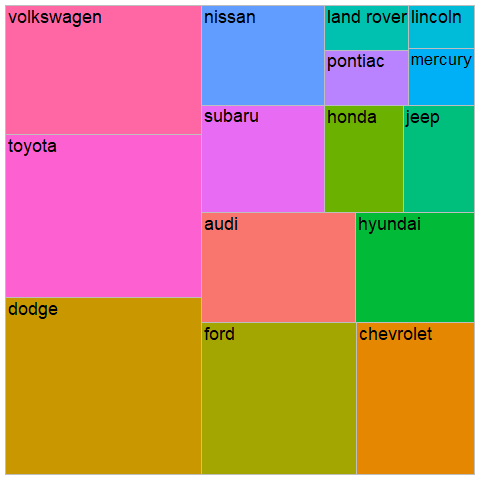

In [78]:
%%R
# Listing 6.6 Simple Tree Map
library(ggplot2)
library(dplyr)
library(treemapify)

plotdata <- mpg %>% count(manufacturer)

ggplot(plotdata,
       aes(fill = manufacturer,
           area = n,
           label = manufacturer)) +
  geom_treemap() +
  geom_treemap_text() +
  theme(legend.position = "none")


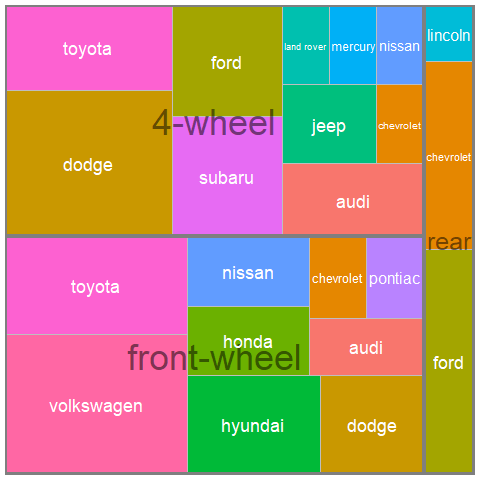

In [79]:
%%R
# Listing 6.7 Tree Map with Subgrouping
plotdata <- mpg %>%  
  count(manufacturer, drv)
plotdata$drv <- factor(plotdata$drv, 
                       levels=c("4", "f", "r"),
                       labels=c("4-wheel", "front-wheel", "rear"))

ggplot(plotdata,
       aes(fill = manufacturer, 
           area = n,
           label = manufacturer,
           subgroup=drv)) +
  geom_treemap() + 
  geom_treemap_subgroup_border() +
  geom_treemap_subgroup_text(
    place = "middle",
    colour = "black",
    alpha = 0.5,
    grow = FALSE) +
  geom_treemap_text(colour = "white", 
                    place = "centre",
                    grow=FALSE) +
  theme(legend.position = "none")


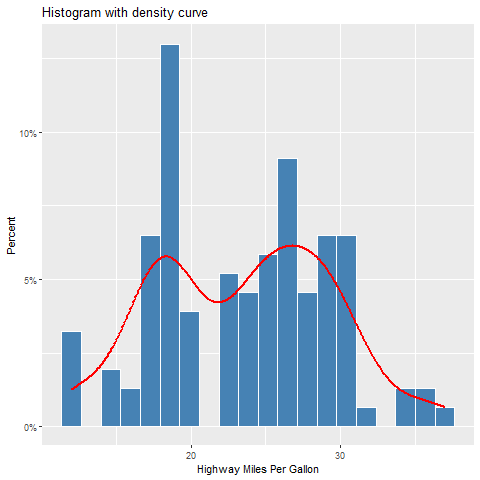

In [80]:
%%R
# Listing 6.8 Histograms
library(ggplot2)
library(scales)

data(mpg)
cars2008 <- mpg[mpg$year == 2008, ]

ggplot(cars2008, aes(x=hwy)) + 
  geom_histogram() +
  labs(title="Default histogram")

ggplot(cars2008, aes(x=hwy)) + 
  geom_histogram(bins=20, color="white", fill="steelblue") +
  labs(title="Colored histogram with 20 bins",
       x="Highway Miles Per Gallon",
       y="Frequency")

ggplot(cars2008, aes(x=hwy, y=..density..)) + 
  geom_histogram(bins=20, color="white", fill="steelblue") +
  scale_y_continuous(labels=scales::percent) +
  labs(title="Histogram with percentages",
       y= "Percent",
       x="Highway Miles Per Gallon")

ggplot(cars2008, aes(x=hwy, y=..density..)) +
  geom_histogram(bins=20, color="white", fill="steelblue") + 
  scale_y_continuous(labels=scales::percent) +
  geom_density(color="red", size=1) +
  labs(title="Histogram with density curve",
       y="Percent" ,
       x="Highway Miles Per Gallon")


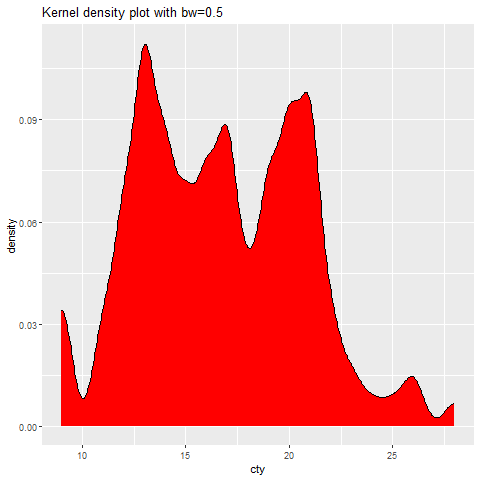

In [81]:
%%R
# Listing 6.9 Kernel density plots
data(mpg, package="ggplot2")
cars2008 <- mpg[mpg$year == 2008, ]

ggplot(cars2008, aes(x=cty)) + 
  geom_density() + 
  labs(title="Default kernel density plot") 

ggplot(cars2008, aes(x=cty)) + 
  geom_density(fill="red") + 
  labs(title="Filled kernel density plot")

bw.nrd0(cars2008$cty)

ggplot(cars2008, aes(x=cty)) + 
  geom_density(fill="red", bw=.5) +
  labs(title="Kernel density plot with bw=0.5")

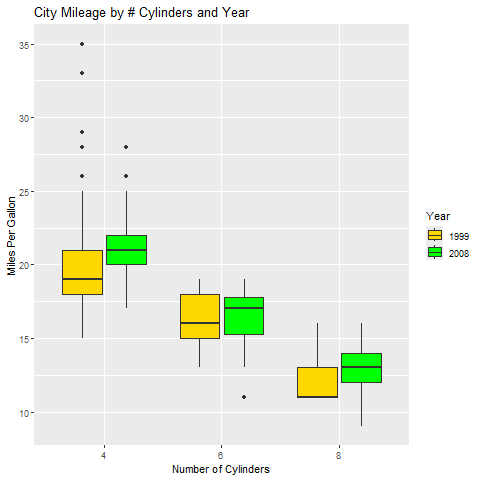

In [82]:
%%R
# Listing 6.10 Comparative kernel density plots
data(mpg, package="ggplot2")
cars2008 <- mpg[mpg$year == 2008 & mpg$cyl != 5,]
cars2008$Cylinders <- factor(cars2008$cyl)

ggplot(cars2008, aes(x=cty, color=Cylinders, linetype=Cylinders)) +
  geom_density(size=1)  +
  labs(title="Fuel Efficiecy by Number of Cylinders",
       x = "City Miles per Gallon")

ggplot(cars2008, aes(x=cty, fill=Cylinders)) + 
  geom_density(alpha=.4) +
  labs(title="Fuel Efficiecy by Number of Cylinders",
       x = "City Miles per Gallon")

# Box plots
ggplot(mtcars, aes(x="", y=mpg)) +
  geom_boxplot() +
  labs(y = "Miles Per Gallon", x="", title="Box Plot")

cars <- mpg[mpg$cyl != 5, ]
cars$Cylinders <- factor(cars$cyl)
cars$Year <- factor(cars$year)
ggplot(cars, aes(x=Cylinders, y=cty)) + 
  geom_boxplot() +
  labs(x="Number of Cylinders", 
       y="Miles Per Gallon", 
       title="Car Mileage Data")

ggplot(cars, aes(x=Cylinders, y=cty)) + 
  geom_boxplot(notch=TRUE, 
               fill="steelblue",
               varwidth=TRUE) +
  labs(x="Number of Cylinders", 
       y="Miles Per Gallon", 
       title="Car Mileage Data")

ggplot(cars, aes(x=Cylinders, y=cty, fill=Year)) +           
  geom_boxplot() +                                           
  labs(x="Number of Cylinders",                              
       y="Miles Per Gallon",                                 
       title="City Mileage by # Cylinders and Year") +    
  scale_fill_manual(values=c("gold", "green"))      


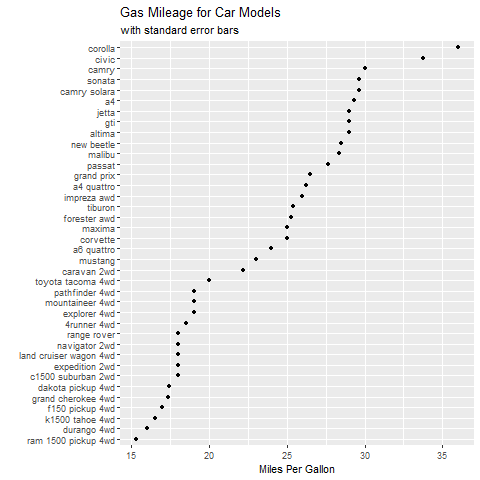

In [83]:
%%R
# Listing 6.11 Violin plots
cars <- mpg[mpg$cyl != 5, ]
cars$Cylinders <- factor(cars$cyl)

ggplot(cars, aes(x=Cylinders, y=cty)) + 
  geom_boxplot(width=0.2, 
               fill="green") +
  geom_violin(fill="gold", 
              alpha=0.3) +
  labs(x="Number of Cylinders", 
       y="City Miles Per Gallon", 
       title="Violin Plots of Miles Per Gallon")

# Dot plots
plotdata <- mpg %>%
  filter(year == "2008") %>%
  group_by(model) %>%
  summarize(meanHwy=mean(hwy))
plotdata

ggplot(plotdata, aes(x=meanHwy, y=model)) + 
  geom_point() +
  labs(x="Miles Per Gallon", 
       y="", 
       title="Gas Mileage for Car Models")

ggplot(plotdata, aes(x=meanHwy, y=reorder(model, meanHwy))) + 
  geom_point() +
  labs(x="Miles Per Gallon", 
       y="", 
       title="Gas Mileage for Car Models",
       subtitle = "with standard error bars")


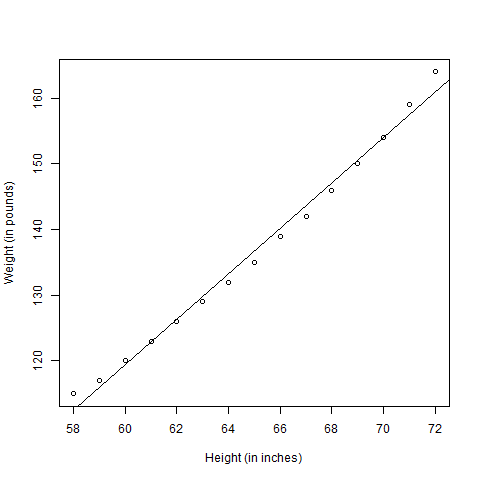

In [84]:
%%R
# Listing 8.1 - Simple linear regression
fit <- lm(weight ~ height, data=women)
summary(fit)
women$weight
fitted(fit)
residuals(fit)

plot(women$height,women$weight, 
     xlab="Height (in inches)", 
     ylab="Weight (in pounds)")
abline(fit)

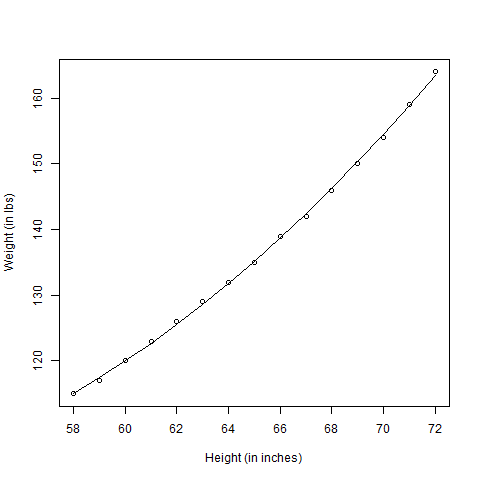

In [85]:
%%R
# Listing 8.2 - Polynomial regression
fit2 <- lm(weight ~ height + I(height^2), data=women)
summary(fit2)

plot(women$height,women$weight,
     xlab="Height (in inches)",
     ylab="Weight (in lbs)")
lines(women$height,fitted(fit2))

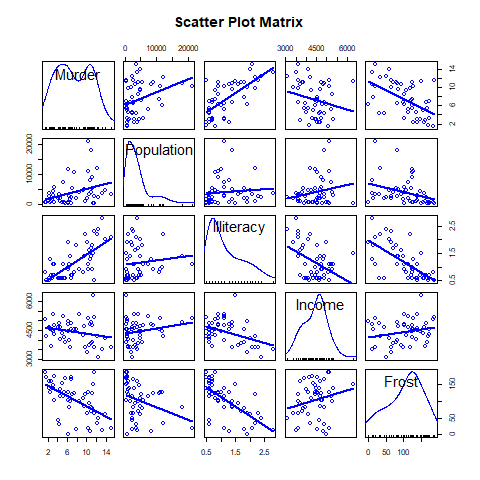

In [86]:
%%R
# Listing 8.3 - Examining bivariate relationships
states <- as.data.frame(state.x77[,c("Murder", "Population", 
                                     "Illiteracy", "Income", "Frost")])
cor(states)
library(car)
scatterplotMatrix(states, smooth=FALSE,
                  main="Scatter Plot Matrix")

In [87]:
%%R
# Listing 8.4 - Multiple linear regression
states <- as.data.frame(state.x77[,c("Murder", "Population", 
                                     "Illiteracy", "Income", "Frost")])
fit <- lm(Murder ~ Population + Illiteracy + Income + Frost, data=states)
summary(fit)


Call:
lm(formula = Murder ~ Population + Illiteracy + Income + Frost, 
    data = states)

Residuals:
    Min      1Q  Median      3Q     Max 
-4.7960 -1.6495 -0.0811  1.4815  7.6210 

Coefficients:
             Estimate Std. Error t value Pr(>|t|)    
(Intercept) 1.235e+00  3.866e+00   0.319   0.7510    
Population  2.237e-04  9.052e-05   2.471   0.0173 *  
Illiteracy  4.143e+00  8.744e-01   4.738 2.19e-05 ***
Income      6.442e-05  6.837e-04   0.094   0.9253    
Frost       5.813e-04  1.005e-02   0.058   0.9541    
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

Residual standard error: 2.535 on 45 degrees of freedom
Multiple R-squared:  0.567,	Adjusted R-squared:  0.5285 
F-statistic: 14.73 on 4 and 45 DF,  p-value: 9.133e-08



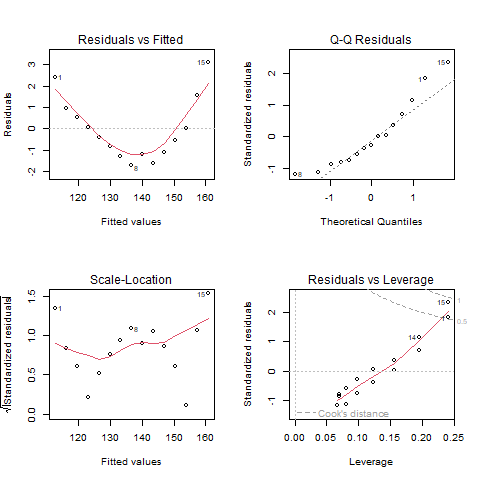

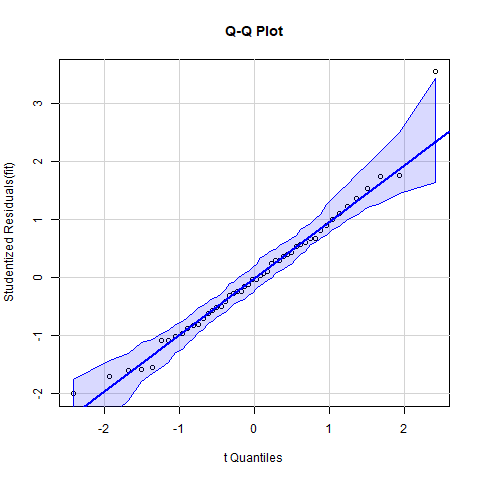

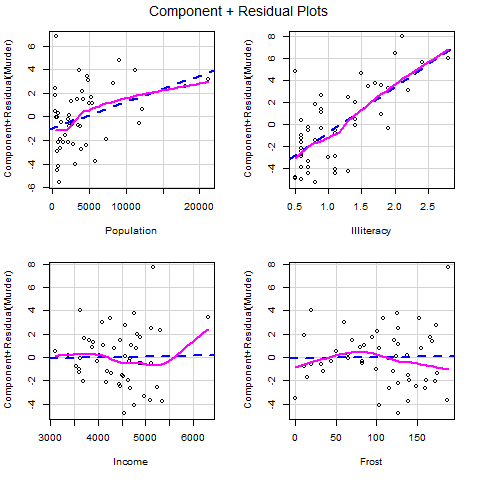

In [88]:
%%R
# Listing 8.5 - Mutiple linear regression with a significant interaction term
fit <- lm(mpg ~ hp + wt + hp:wt, data=mtcars)
summary(fit)

library(effects)
plot(effect("hp:wt", fit,, list(wt=c(2.2, 3.2, 4.2))), lines=c(1,2,3), multiline=TRUE)


# simple regression diagnostics
fit <- lm(weight ~ height, data=women)
par(mfrow=c(2,2))
plot(fit)
par(mfrow=c(1,1))


# Assessing normality
library(car)
states <- as.data.frame(state.x77[,c("Murder", "Population",
                                     "Illiteracy", "Income", "Frost")])
fit <- lm(Murder ~ Population + Illiteracy + Income + Frost, data=states)
qqPlot(fit, simulate=TRUE, labels=row.names(states),
       id=list(method="identify"), main="Q-Q Plot")


# Independence of errors
durbinWatsonTest(fit)

# Assessing linearity
library(car)
crPlots(fit)


Suggested power transformation:  1.209626 


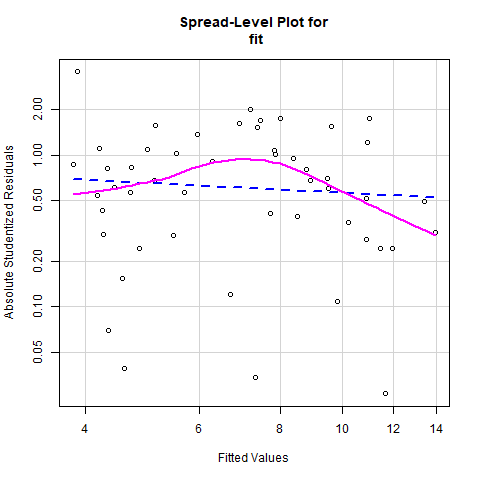

In [89]:
%%R
# Listing 8.6 - Assessing homoscedasticity
library(car)
ncvTest(fit)
spreadLevelPlot(fit)

                StudRes        Hat       CookD
Alaska        1.7536917 0.43247319 0.448050997
California   -0.2761492 0.34087628 0.008052956
Nevada        3.5429286 0.09508977 0.209915743
Rhode Island -2.0001631 0.04562377 0.035858963


In addition: Warning message:
In applyDefaults(id, defaults = list(method = "noteworthy", n = 2,  :
  unnamed id arguments, will be ignored


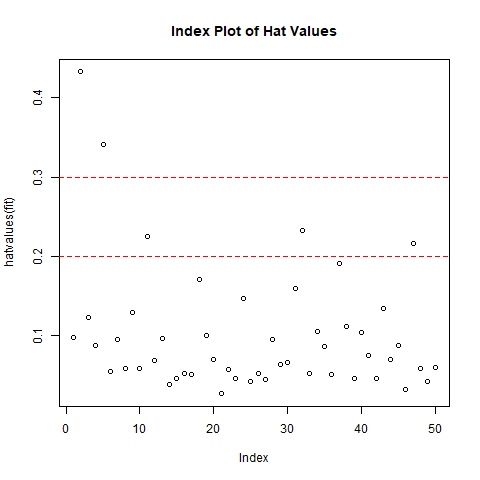

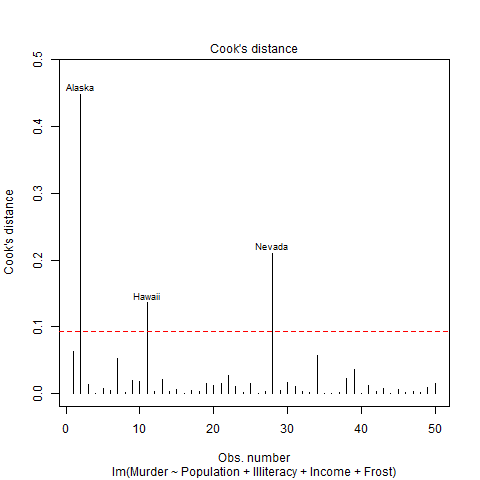

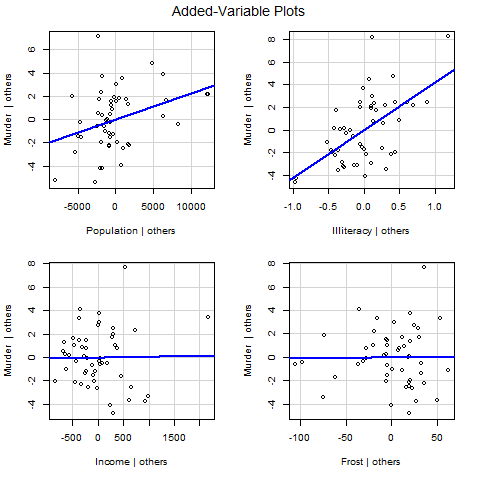

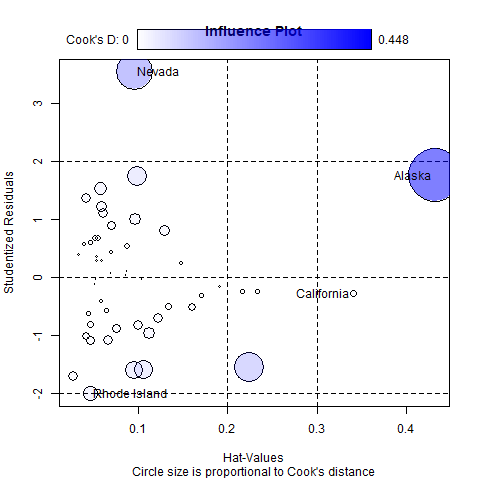

In [90]:
%%R
# Listing 8.7 - Evaluating multi-collinearity
library(car)
vif(fit) 
vif(fit) > 10 # problem?

# Assessing outliers
library(car)
outlierTest(fit)

#  Identifying high leverage points
# redo as ggplot2?
hat.plot <- function(fit) {
  p <- length(coefficients(fit))
  n <- length(fitted(fit))
  plot(hatvalues(fit), main="Index Plot of Hat Values")
  abline(h=c(2,3)*p/n, col="red", lty=2)
  identify(1:n, hatvalues(fit), names(hatvalues(fit)))
}
hat.plot(fit)

# Identifying influential observations

# Cooks Distance D
# identify D values > 4/(n-k-1) 
cutoff <- 4/(nrow(states)-length(fit$coefficients)-2)
plot(fit, which=4, cook.levels=cutoff)
abline(h=cutoff, lty=2, col="red")


# Added variable plots
# add id.method="identify" to interactively identify points
library(car)
avPlots(fit, ask=FALSE, id=list(method="identify"))


# Influence Plot
library(car)
influencePlot(fit, id="noteworthy", main="Influence Plot",
              sub="Circle size is proportional to Cook's distance")



In [91]:
%%R
# Listing 8.10 - Box-Cox Transformation to normality
library(car)
summary(powerTransform(states$Murder))

# Box-Tidwell Transformations to linearity
library(car)
boxTidwell(Murder~Population+Illiteracy,data=states)


           MLE of lambda Score Statistic (t) Pr(>|t|)
Population       0.86939             -0.3228   0.7483
Illiteracy       1.35812              0.6194   0.5388

iterations =  19 

Score test for null hypothesis that all lambdas = 1:
F = 0.23214, df = 2 and 45, Pr(>F) = 0.7938



In [92]:
%%R
# Listing 8.11 - Comparing nested models using the anova function
states <- as.data.frame(state.x77[,c("Murder", "Population",
                                     "Illiteracy", "Income", "Frost")])
fit1 <- lm(Murder ~ Population + Illiteracy + Income + Frost,
           data=states)
fit2 <- lm(Murder ~ Population + Illiteracy, data=states)
anova(fit2, fit1)

Analysis of Variance Table

Model 1: Murder ~ Population + Illiteracy
Model 2: Murder ~ Population + Illiteracy + Income + Frost
  Res.Df    RSS Df Sum of Sq      F Pr(>F)
1     47 289.25                           
2     45 289.17  2  0.078505 0.0061 0.9939


In [93]:
%%R
# Listing 8.12 - Comparing models with the AIC
fit1 <- lm(Murder ~ Population + Illiteracy + Income + Frost,
           data=states)
fit2 <- lm(Murder ~ Population + Illiteracy, data=states)
AIC(fit1,fit2)

     df      AIC
fit1  6 241.6429
fit2  4 237.6565


In [94]:
%%R
# Listing 8.13 - Backward stepwise selection
states <- as.data.frame(state.x77[,c("Murder", "Population",
                                     "Illiteracy", "Income", "Frost")])
fit <- lm(Murder ~ Population + Illiteracy + Income + Frost,
          data=states)
step(fit, direction="backward")

Start:  AIC=97.75
Murder ~ Population + Illiteracy + Income + Frost

             Df Sum of Sq    RSS     AIC
- Frost       1     0.021 289.19  95.753
- Income      1     0.057 289.22  95.759
<none>                    289.17  97.749
- Population  1    39.238 328.41 102.111
- Illiteracy  1   144.264 433.43 115.986

Step:  AIC=95.75
Murder ~ Population + Illiteracy + Income

             Df Sum of Sq    RSS     AIC
- Income      1     0.057 289.25  93.763
<none>                    289.19  95.753
- Population  1    43.658 332.85 100.783
- Illiteracy  1   236.196 525.38 123.605

Step:  AIC=93.76
Murder ~ Population + Illiteracy

             Df Sum of Sq    RSS     AIC
<none>                    289.25  93.763
- Population  1    48.517 337.76  99.516
- Illiteracy  1   299.646 588.89 127.311

Call:
lm(formula = Murder ~ Population + Illiteracy, data = states)

Coefficients:
(Intercept)   Population   Illiteracy  
  1.6515497    0.0002242    4.0807366  



In [95]:
%%R
# Listing 8.14 - All subsets regression
library(leaps)
states <- as.data.frame(state.x77[,c("Murder", "Population", 
                                     "Illiteracy", "Income", "Frost")])

leaps <-regsubsets(Murder ~ Population + Illiteracy + Income +
                     Frost, data=states, nbest=4)

subsTable <- function(obj, scale){
  x <- summary(leaps)
  m <- cbind(round(x[[scale]],3), x$which[,-1])
  colnames(m)[1] <- scale
  m[order(m[,1]), ]
}

subsTable(leaps, scale="adjr2")

  adjr2 Population Illiteracy Income Frost
1 0.033          0          0      1     0
1 0.100          1          0      0     0
1 0.276          0          0      0     1
2 0.292          1          0      0     1
3 0.309          1          0      1     1
3 0.476          0          1      1     1
2 0.480          0          1      1     0
2 0.481          0          1      0     1
1 0.484          0          1      0     0
4 0.528          1          1      1     1
3 0.539          1          1      1     0
3 0.539          1          1      0     1
2 0.548          1          1      0     0


In [96]:
%%R
# Listing 8.15 - Function for k-fold cross-validated R-square

shrinkage <- function(fit, k=10, seed=1){
  require(bootstrap)
  
  theta.fit <- function(x,y){lsfit(x,y)}                     
  theta.predict <- function(fit,x){cbind(1,x)%*%fit$coef}     
  
  x <- fit$model[,2:ncol(fit$model)]                         
  y <- fit$model[,1] 
  
  set.seed(seed)
  results <- crossval(x, y, theta.fit, theta.predict, ngroup=k)  
  r2    <- cor(y, fit$fitted.values)^2                         
  r2cv  <- cor(y, results$cv.fit)^2
  cat("Original R-square =", r2, "\n")
  cat(k, "Fold Cross-Validated R-square =", r2cv, "\n")
}

states <- as.data.frame(state.x77[,c("Murder", "Population", 
                                     "Illiteracy", "Income", "Frost")])
fit <- lm(Murder ~ Population + Income + Illiteracy + Frost, data=states)
shrinkage(fit)

fit2 <- lm(Murder ~ Population + Illiteracy,data=states)
shrinkage(fit2)

Original R-square = 0.5669502 
10 Fold Cross-Validated R-square = 0.3564904 
Original R-square = 0.5668327 
10 Fold Cross-Validated R-square = 0.514864 


             Weights
Income      5.488962
Population 14.723401
Frost      20.787442
Illiteracy 59.000195


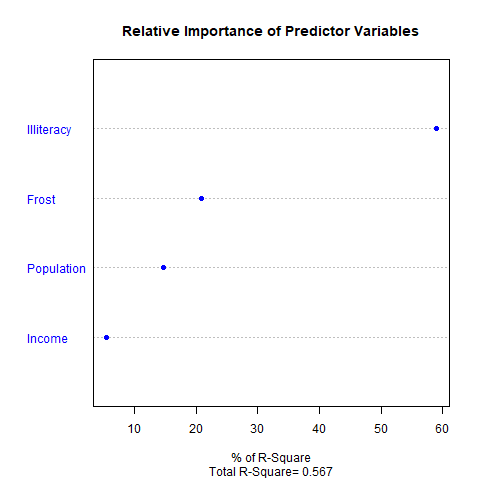

In [97]:
%%R
relweights <- function(fit,...){
  R <- cor(fit$model)
  nvar <- ncol(R)
  rxx <- R[2:nvar, 2:nvar]
  rxy <- R[2:nvar, 1]
  svd <- eigen(rxx)
  evec <- svd$vectors
  ev <- svd$values
  delta <- diag(sqrt(ev))
  lambda <- evec %*% delta %*% t(evec)
  lambdasq <- lambda ^ 2
  beta <- solve(lambda) %*% rxy
  rsquare <- colSums(beta ^ 2)
  rawwgt <- lambdasq %*% beta ^ 2
  import <- (rawwgt / rsquare) * 100
  import <- as.data.frame(import)
  row.names(import) <- names(fit$model[2:nvar])
  names(import) <- "Weights"
  import <- import[order(import$Weights), , drop=FALSE]  # fixed line
  dotchart(import$Weights, labels=row.names(import),
           xlab="% of R-Square", pch=19,
           main="Relative Importance of Predictor Variables",
           sub=paste("Total R-Square=", round(rsquare, digits=3)),
           ...)
  return(import)
}

states <- as.data.frame(state.x77[,c("Murder", "Population",
                                     "Illiteracy", "Income", "Frost")])
fit <- lm(Murder ~ Population + Illiteracy + Income + Frost, data=states)
relweights(fit, col="blue")

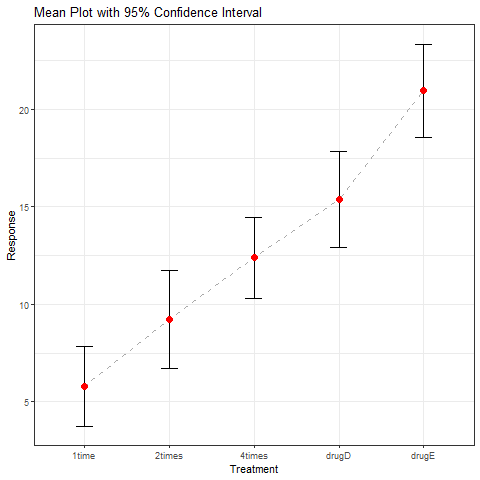

In [98]:
%%R
# Listing 9.1 - One-way ANOVA
data(cholesterol, package="multcomp")


library(dplyr)
plotdata <- cholesterol %>%
  group_by(trt) %>%
  summarize(n = n(),
            mean = mean(response),
            sd = sd(response),
            ci = qt(0.975, df = n - 1) * sd / sqrt(n))
plotdata

fit <- aov(response ~ trt, data=cholesterol)                                  
summary(fit)


library(ggplot2)
ggplot(plotdata, 
       aes(x = trt, y = mean, group = 1)) +
  geom_line(linetype="dashed", color="darkgrey") + 
  geom_errorbar(aes(ymin = mean - ci, 
                    ymax = mean + ci), 
                width = .2) +
  geom_point(size = 3, color="red") +
  theme_bw() + 
  labs(x="Treatment",
       y="Response",
       title="Mean Plot with 95% Confidence Interval") 


No Studentized residuals with Bonferroni p < 0.05
Largest |rstudent|:
   rstudent unadjusted p-value Bonferroni p
19 2.251149           0.029422           NA


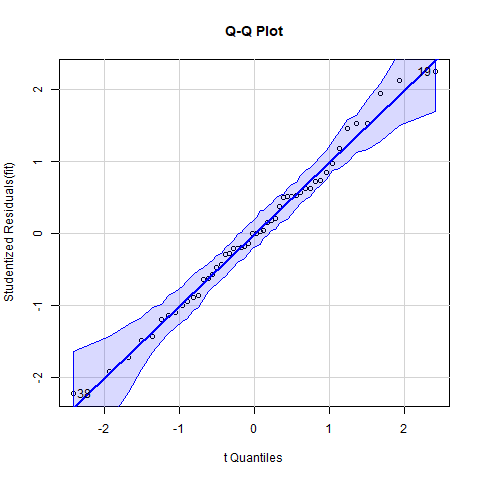

In [99]:
%%R
# Listing 9.2 - Tukey HSD pairwise group comparisons
pairwise <- TukeyHSD(fit)
pairwise

plotdata <- as.data.frame(pairwise[[1]])
plotdata$conditions <- row.names(plotdata)

library(ggplot2)
ggplot(data=plotdata, aes(x=conditions, y=diff)) + 
  geom_errorbar(aes(ymin=lwr, ymax=upr, width=.2)) +
  geom_hline(yintercept=0, color="red", linetype="dashed") +
  geom_point(size=3, color="red") +
  theme_bw() +
  labs(y="Difference in mean levels", x="", 
       title="95% family-wise confidence level") +
   coord_flip()



# Multiple comparisons the multcomp package
library(multcomp)
tuk <- glht(fit, linfct=mcp(trt="Tukey")) 
summary(tuk)

labels1 <- cld(tuk, level=.05)$mcletters$Letters
labels2 <- paste(names(labels1), "\n", labels1)
ggplot(data=fit$model, aes(x=trt, y=response)) +
  scale_x_discrete(breaks=names(labels1), labels=labels2) +
  geom_boxplot(fill="lightgrey") +
  theme_bw() +
  labs(x="Treatment",
       title="Distribution of Response Scores by Treatment",
       subtitle="Groups without overlapping letters differ signifcantly (p < .05)")


# Assessing normality
library(car)
qqPlot(fit, simulate=TRUE, main="Q-Q Plot")

# Assessing homogeneity of variances
bartlett.test(response ~ trt, data=cholesterol)

# Assessing outliers
library(car)
outlierTest(fit)

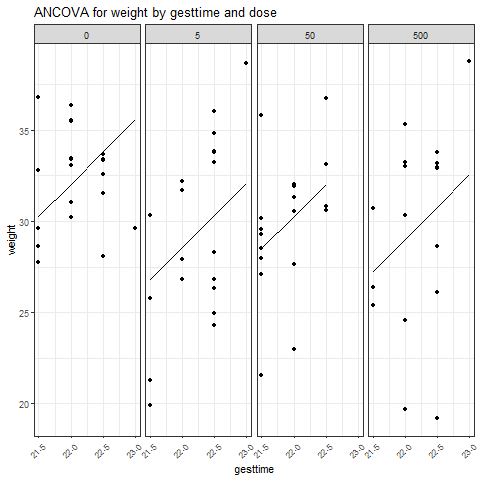

In [100]:
%%R
# Listing 9.5 - Testing for homegeneity of regression slopes
library(multcomp)
library(ggplot2)

# Testing for homogeneity of regression slopes
fit2 <- aov(weight ~ gesttime*dose, data=litter)
summary(fit2)

# Redefine fit in the same cell to ensure row counts match
fit <- aov(weight ~ gesttime + dose, data=litter)
pred <- predict(fit)

ggplot(data = cbind(litter, pred),
       aes(gesttime, weight)) + geom_point() +
  facet_grid(. ~ dose) + geom_line(aes(y=pred)) +
  labs(title="ANCOVA for weight by gesttime and dose") +
  theme_bw() +
  theme(axis.text.x = element_text(angle=45, hjust=1),
        legend.position="none")

`summarise()` has grouped output by 'supp'. You can override using the
`.groups` argument.


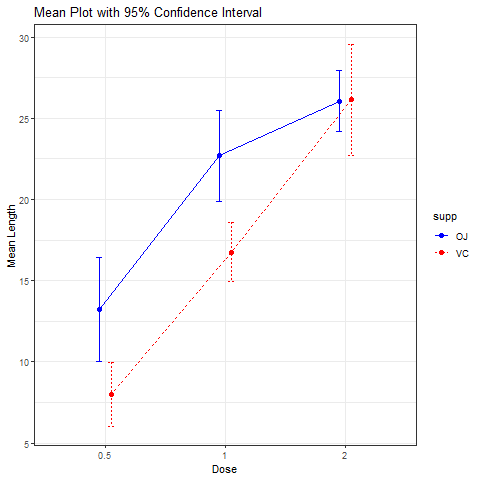

In [101]:
%%R
# Listing 9.6 - Two way ANOVA
data(ToothGrowth)
library(dplyr)
ToothGrowth$dose <- factor(ToothGrowth$dose)
stats <- ToothGrowth %>%
  group_by(supp, dose) %>%
  summarise(n=n(), mean=mean(len), sd=sd(len),
            ci = qt(0.975, df = n - 1) * sd / sqrt(n))
stats


fit <- aov(len ~ supp*dose, data=ToothGrowth)
summary(fit)

# plotting interactions
library(ggplot2)
pd <- position_dodge(0.2)
ggplot(stats, 
       aes(x = dose, y = mean, 
           group=supp, 
           color=supp, 
           linetype=supp)) +
  geom_point(size = 2, 
             position=pd) +
  geom_line(position=pd) +
  geom_errorbar(aes(ymin = mean - ci, ymax = mean + ci), 
                width = .1, 
                position=pd) +
  theme_bw() + 
  scale_color_manual(values=c("blue", "red")) +
  labs(x="Dose",
       y="Mean Length",
       title="Mean Plot with 95% Confidence Interval") 

`summarise()` has grouped output by 'conc'. You can override using the
`.groups` argument.


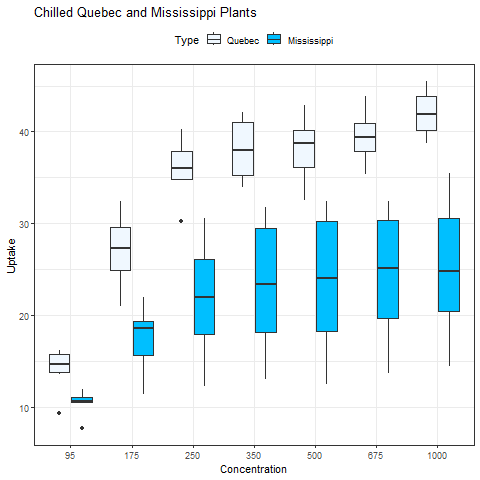

In [102]:
%%R
#  Listing 9.7 - Repeated measures ANOVA with one between and within groups factor
data(CO2)
CO2$conc <- factor(CO2$conc)
w1b1 <- subset(CO2, Treatment=='chilled')
fit <- aov(uptake ~ (conc*Type) + Error(Plant/(conc)), w1b1)
summary(fit)

library(dplyr)
plotdata <- CO2 %>%
  group_by(conc, Type) %>%
  summarise(mean_conc = mean(uptake))

library(ggplot2)
ggplot(data=plotdata, aes(x=conc, y=mean_conc, group=Type, color=Type,
                          linetype=Type)) +
  geom_point(size=2) +
  geom_line(size=1) +
  theme_bw() + theme(legend.position="top") +
  labs(x="Concentration", y="Mean Uptake", 
       title="Interaction Plot for Plant Type and Concentration")

library(ggplot2)
ggplot(data=CO2, aes(x=conc, y=uptake, fill=Type)) +
  geom_boxplot() +
  theme_bw() + theme(legend.position="top") +
  scale_fill_manual(values=c("aliceblue", "deepskyblue"))+
  labs(x="Concentration", y="Uptake", 
       title="Chilled Quebec and Mississippi Plants")


Projection to the first and second robust principal components.
Proportion of total variation (explained variance): 0.9789888

	Robust One-way MANOVA (Bartlett Chi2)

data:  x
Wilks' Lambda = 0.42394, Chi2-Value = 21.3635, DF = 4.1315, p-value =
0.0003063
sample estimates:
  calories       fat    sugars
1 118.1432 0.7449005  5.100422
2 126.7149 1.0724502 12.761427
3 160.1003 1.6591192  9.913359



Loading required package: sgeostat
Loading required package: robustbase

Attaching package: 'robustbase'

The following object is masked from 'package:survival':

    heart

Scalable Robust Estimators with High Breakdown Point (version 1.7-7)

In addition: Warning messages:
1: package 'mvoutlier' was built under R version 4.5.2 
2: package 'sgeostat' was built under R version 4.5.2 
3: package 'rrcov' was built under R version 4.5.2 
4: package 'robustbase' was built under R version 4.5.2 


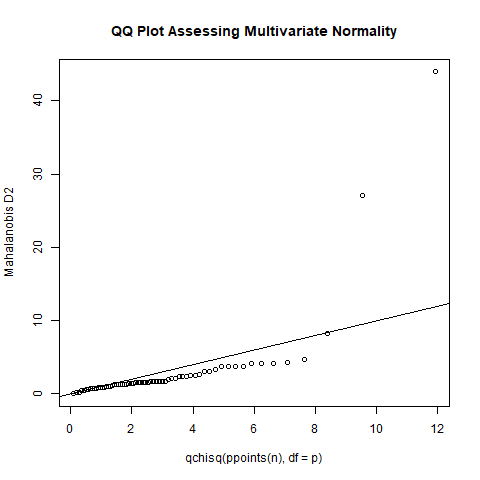

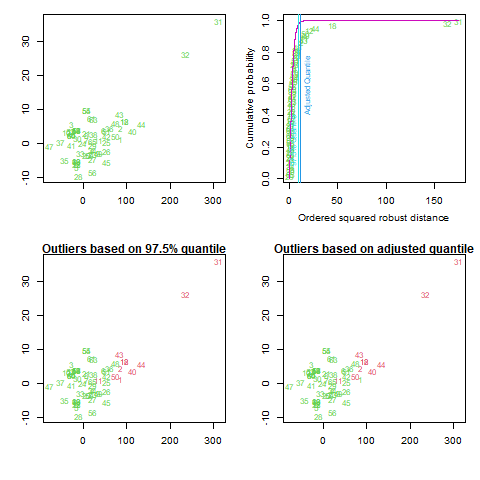

In [104]:
%%R
# Listing 9.8 - One-way MANOVA
data(UScereal, package="MASS")
shelf <- factor(UScereal$shelf) 
y <- cbind(UScereal$calories, UScereal$fat, UScereal$sugars)
colnames(y) <- c("calories", "fat", "sugars")
aggregate(y, by=list(shelf=shelf), FUN=mean)
round(cov(y), 2)
fit <- manova(y ~ shelf)
summary(fit)
summary.aov(fit)


#  Listing 9.9 - Assessing multivariate normality
center <- colMeans(y)
n <- nrow(y)
p <- ncol(y)
cov <- cov(y)
d <- mahalanobis(y,center,cov)
coord <- qqplot(qchisq(ppoints(n),df=p),
                d, main="QQ Plot Assessing Multivariate Normality",
                ylab="Mahalanobis D2")
abline(a=0,b=1)
identify(coord$x, coord$y, labels=row.names(UScereal))


# multivariate outliers
library(mvoutlier)
outliers <- aq.plot(y)
outliers

# Listing 9.10 - Robust one-way MANOVA
library(rrcov)
Wilks.test(y,shelf, method="mcd")  # this can take a while

In [105]:
%%R
# Listing 9.11 - A regression approach to the Anova problem
fit.lm <- lm(response ~ trt, data=cholesterol)
summary(fit.lm)
contrasts(cholesterol$trt)

       2times 4times drugD drugE
1time       0      0     0     0
2times      1      0     0     0
4times      0      1     0     0
drugD       0      0     1     0
drugE       0      0     0     1
